## Autoencoder Baseline

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, 
                             average_precision_score, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load data
df = pd.read_csv('../data/creditcard.csv')
df['Hour'] = (df['Time'] / 3600) % 24
df['Log_Amount'] = np.log1p(df['Amount'])

# Time-based split
split_idx = int(len(df) * 0.8)
train_df = df[:split_idx].copy()
test_df = df[split_idx:].copy()

# Use only normal transactions for training
train_normal = train_df[train_df['Class'] == 0]

# Features
feature_cols = [col for col in df.columns if col not in ['Time', 'Class']]
X_train_normal = train_normal[feature_cols].values
X_test = test_df[feature_cols].values
y_test = test_df['Class'].values

# Scale
scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples (normal only): {len(X_train_normal_scaled)}")
print(f"Test samples: {len(X_test_scaled)}")
print(f"Number of features: {X_train_normal_scaled.shape[1]}")

Using device: cpu
Training samples (normal only): 227428
Test samples: 56962
Number of features: 31


## Define Autoencoder Architecture

In [2]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=14):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 24),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(24, encoding_dim),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 24),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(24, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        return self.encoder(x)

# Initialize model
input_dim = X_train_normal_scaled.shape[1]
model = Autoencoder(input_dim=input_dim, encoding_dim=14).to(device)

print("\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")


Model Architecture:
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=31, out_features=24, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=24, out_features=14, bias=True)
    (4): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=14, out_features=24, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=24, out_features=31, bias=True)
  )
)

Total parameters: 2253


## Creating Dataset and DataLoader

In [3]:
class FraudDataset(Dataset):
    def __init__(self, data):
        self.data = torch.FloatTensor(data)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

# Create datasets
train_dataset = FraudDataset(X_train_normal_scaled)
test_dataset = FraudDataset(X_test_scaled)

# Create dataloaders
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Training Loop


TRAINING AUTOENCODER
Epoch [10/50], Loss: 0.536744
Epoch [20/50], Loss: 0.511295
Epoch [30/50], Loss: 0.503235
Epoch [40/50], Loss: 0.499582
Epoch [50/50], Loss: 0.502249


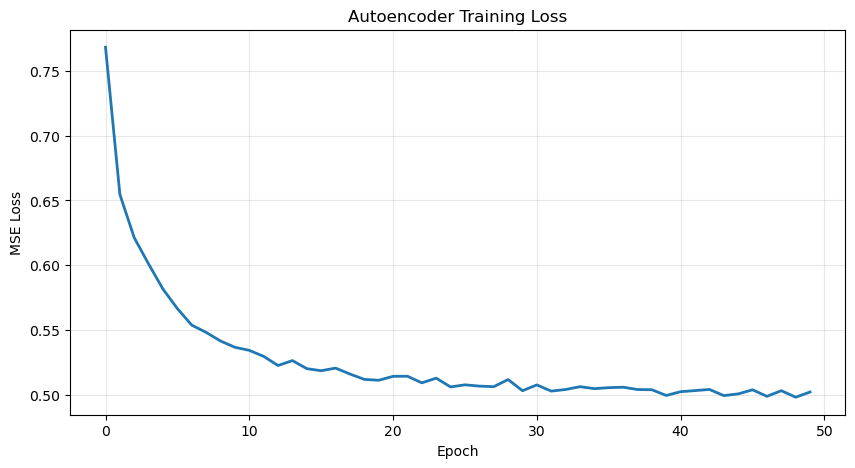

In [4]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
num_epochs = 50
train_losses = []

print("\n" + "="*60)
print("TRAINING AUTOENCODER")
print("="*60)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        
        # Forward pass
        outputs = model(batch)
        loss = criterion(outputs, batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss')
plt.grid(True, alpha=0.3)
plt.savefig('../images/autoencoder_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation with Reconstruction Error

In [5]:
# Calculate reconstruction errors
model.eval()
reconstruction_errors = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        outputs = model(batch)
        
        # Calculate MSE for each sample
        errors = torch.mean((batch - outputs) ** 2, dim=1)
        reconstruction_errors.extend(errors.cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)

print("\n" + "="*60)
print("AUTOENCODER EVALUATION")
print("="*60)

# Use reconstruction error as anomaly score
threshold = np.percentile(reconstruction_errors, 95)  # Top 5% as anomalies
y_pred_ae = (reconstruction_errors > threshold).astype(int)

print(f"\nReconstruction Error Threshold: {threshold:.6f}")
print(f"Predicted anomalies: {y_pred_ae.sum()}")
print(f"Actual frauds: {y_test.sum()}")

# Metrics
roc_auc = roc_auc_score(y_test, reconstruction_errors)
pr_auc = average_precision_score(y_test, reconstruction_errors)

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ae, target_names=['Normal', 'Fraud']))


AUTOENCODER EVALUATION

Reconstruction Error Threshold: 0.838580
Predicted anomalies: 2849
Actual frauds: 75

ROC-AUC Score: 0.9537
PR-AUC Score: 0.2409

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56887
       Fraud       0.02      0.84      0.04        75

    accuracy                           0.95     56962
   macro avg       0.51      0.90      0.51     56962
weighted avg       1.00      0.95      0.97     56962



## Visualization

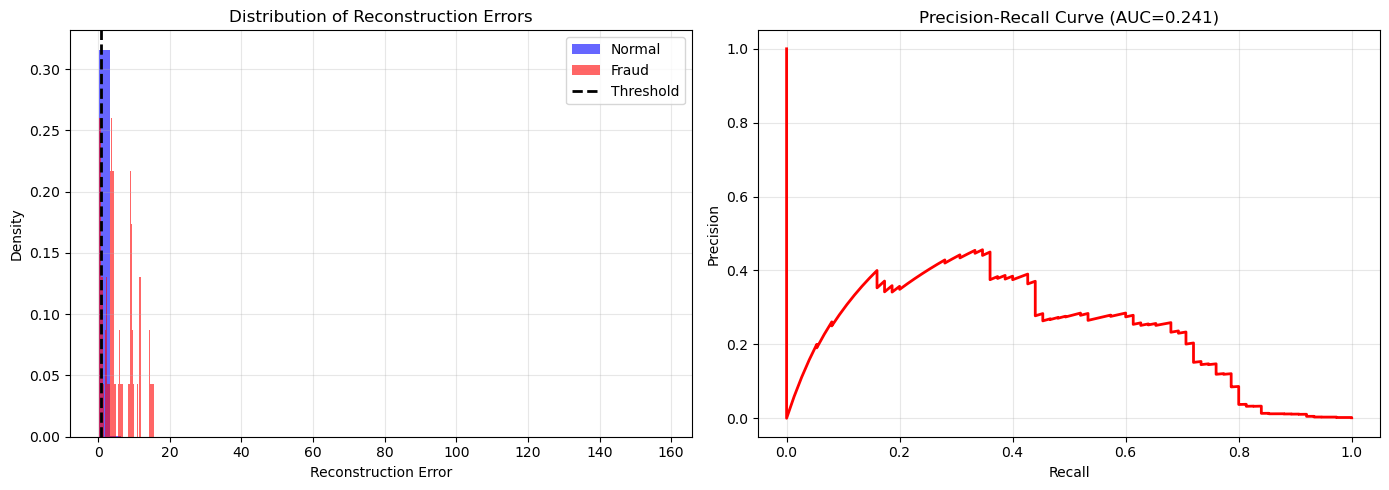

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of reconstruction errors
axes[0].hist(reconstruction_errors[y_test == 0], bins=50, alpha=0.6,
             label='Normal', color='blue', density=True)
axes[0].hist(reconstruction_errors[y_test == 1], bins=50, alpha=0.6,
             label='Fraud', color='red', density=True)
axes[0].axvline(threshold, color='black', linestyle='--', linewidth=2, 
                label='Threshold')
axes[0].set_xlabel('Reconstruction Error')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Reconstruction Errors')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, reconstruction_errors)
axes[1].plot(recall, precision, color='red', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (AUC={pr_auc:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/autoencoder_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Model

In [8]:
# Save model and scaler
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': input_dim,
    'encoding_dim': 14,
    'threshold': threshold
}, '../models/autoencoder_fraud.pth')

import joblib
joblib.dump(scaler, '../models/scaler.pkl')

print("\nModel saved to: ../models/autoencoder_fraud.pth")
print("Scaler saved to: ../models/scaler.pkl")


Model saved to: ../models/autoencoder_fraud.pth
Scaler saved to: ../models/scaler.pkl
